<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - **Main Notes 2026/01** (Francisco Förster Burón):  
>   - https://github.com/fforster/AS4501/tree/main
> - Valetino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> and previour teachers assistants
> Paula Caceres, Javiera Toro, Melissa FuenteAlba, ..

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astroML.datasets

rc_params = {
   'mathtext.fontset': 'cm',     # Set default mathtext font
   'font.family': 'STIXGeneral', # Set default font family
   'xtick.direction': 'in',      # Set default xtickdirecion
   'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
   'ytick.direction': 'in',      # Set default ytickdirecion
   'ytick.minor.visible': True,  # visibility of minor ticks on y-axis
   'grid.linestyle': ':',        # Set grid linestyle
   'grid.alpha': 0.6,            # Set grid transparency
   
}
plt.rcParams.update(rc_params)

CSPEED = 3e5 # km/s

We will use the `astroML.datasets.generate_mu_z` module to create a simulated dataset of redshift vs. luminosity distance. The library outputs the distance modulus ($\mu$), so we first need to convert it into luminosity distance ($d_L$, in Megaparsecs) using the following formula:

$$\mu = 5 \log_{10}(d_L) + 25$$

Solving for $d_L$, we get:
$$d_L = 10^{\frac{\mu - 25}{5}}$$

For this regression exercise, we are assuming a simple linear relationship:
$$d_L = \theta_1 z + \theta_0$$

where $d_L$ is the luminosity distance, $z$ is the redshift, and $\theta_1$ and $\theta_0$ are the slope and intercept, respectively. Physically, at low redshifts ($z \ll 1$), this linear relationship represents Hubble's Law ($cz = H_0 d_L$). Therefore, the slope $\theta_1$ is directly related to the Hubble Constant ($H_0$) by the relation $\theta_1 = c / H_0$, where $c$ is the speed of light.In vector form, this can be expressed as the product of the parameter row vector $\boldsymbol{\theta}^T$ and the feature column vector $\mathbf{x}$:

$$d_L = \boldsymbol{\theta}^T \mathbf{z} = \begin{pmatrix} \theta_1 & \theta_0 \end{pmatrix} \begin{pmatrix} z \\ 1 \end{pmatrix}$$

The expected value in this notebook is $H_0 = 71 \text{ km/s/Mpc}$.

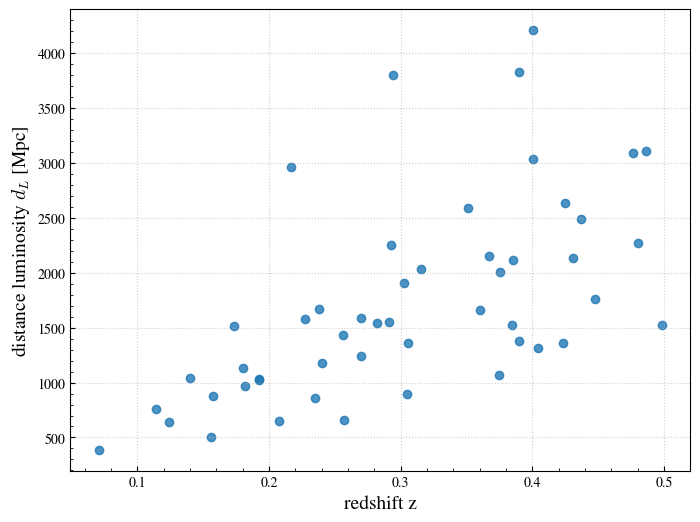

In [116]:
# Genererating data
z_sample, mu_sample, _  = astroML.datasets.generate_mu_z(100, random_state=42)
mask = z_sample < 0.5
z_sample, mu_sample  = z_sample[mask], mu_sample[mask]
mu2dl     = lambda mu: 10**((mu - 25) / 5)
dL_sample = mu2dl(mu_sample) #/ 1000 # Convert to Gpc


fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_sample, dL_sample, alpha=0.8)
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance luminosity $d_L$ [Mpc]', fontsize=14)
plt.grid()
plt.show()

In [117]:
X = z_sample.reshape(-1, 1)
y = dL_sample

print('Redshift z:', z_sample,'\n', 'Shape:', z_sample.shape, end='\n\n')
print('Matrix X:', X,'\n', 'Shape:', X.shape, end='\n\n')
print('Distance modulus mu:', y,'\n', 'Shape:', y.shape, end='\n\n')

Redshift z: [0.436657   0.27005693 0.2700366  0.17312131 0.11413956 0.3154359
 0.29131424 0.29258659 0.38462246 0.47995544 0.37498936 0.25587674
 0.37566788 0.43057269 0.49859179 0.30553284 0.15773364 0.28212075
 0.1816404  0.38489719 0.21699618 0.48626001 0.24026268 0.13960262
 0.35081231 0.39014304 0.29375198 0.20764192 0.30261964 0.1560119
 0.40020283 0.44721399 0.36021212 0.42344165 0.36734864 0.2571252
 0.19260711 0.30477788 0.07053003 0.19203936 0.42471132 0.23455457
 0.40431526 0.17985184 0.38960456 0.40009425 0.23801444 0.47658646
 0.12386752 0.22700015] 
 Shape: (50,)

Matrix X: [[0.436657  ]
 [0.27005693]
 [0.2700366 ]
 [0.17312131]
 [0.11413956]
 [0.3154359 ]
 [0.29131424]
 [0.29258659]
 [0.38462246]
 [0.47995544]
 [0.37498936]
 [0.25587674]
 [0.37566788]
 [0.43057269]
 [0.49859179]
 [0.30553284]
 [0.15773364]
 [0.28212075]
 [0.1816404 ]
 [0.38489719]
 [0.21699618]
 [0.48626001]
 [0.24026268]
 [0.13960262]
 [0.35081231]
 [0.39014304]
 [0.29375198]
 [0.20764192]
 [0.30261964]

Assuming that the true relationship between our variables is linear, but our measurements (e.g., flux from a telescope) contain a random error $\epsilon_i$:

$$y_i = \mathbf{X}_i \theta + \epsilon_i$$

By the Central Limit Theorem, we can assume that this instrumental noise is normally distributed with a mean of zero and a constant variance $\sigma^2$, such that $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$. Therefore, the probability of observing a specific value $y_i$, given our features $\mathbf{X}_i$ and parameterized by our model $\theta$, follows a Gaussian distribution:

$$P(y_i | \mathbf{X}_i; \theta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(y_i - \mathbf{X}_i\theta)^2}{2\sigma^2} \right)$$

We want to find the model parameters $\theta$ that maximize the probability of obtaining the data we actually observed. Assuming that our $n$ observations (for instance, a sample of 100 supernovae) are independent, the total joint probability is the product of their individual probabilities. This is known as the Likelihood Function, $L(\theta)$:

$$L(\theta) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(y_i - \mathbf{X}_i\theta)^2}{2\sigma^2} \right)$$

Since the natural logarithm is a strictly increasing function, the value of $\theta$ that maximizes $L(\theta)$ will also maximize its logarithm, $\ln L(\theta)$. Using the log-likelihood is mathematically convenient because it converts the product into a sum and "brings down" the exponent of the Gaussian:
$$
\begin{aligned}
\ln L(\theta) &= \sum_{i=1}^{n} \ln \left[ \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(y_i - \mathbf{X}_i\theta)^2}{2\sigma^2} \right) \right] \\
\ln L(\theta) &= n \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \sum_{i=1}^{n} \frac{(y_i - \mathbf{X}_i\theta)^2}{2\sigma^2}
\end{aligned}
$$
To maximize the log-likelihood with respect to $\theta$, we can ignore the first term because it is a constant (it does not depend on $\theta$). Furthermore, the factor $\frac{1}{2\sigma^2}$ in the second term is also a positive constant multiplier. Thus, maximizing the overall probability is mathematically equivalent to minimizing the subtracted squared term:

$$\text{Minimize:} \sum_{i=1}^{n} (y_i - \mathbf{X}_i\theta)^2$$

This demonstrates that minimizing the Residual Sum of Squares (RSS) in Ordinary Least Squares (OLS) is exactly equivalent to performing Maximum Likelihood Estimation under the assumption of Gaussian noise.

To find the optimal parameters for our linear model, we minimize the **Residual Sum of Squares (RSS)**. The cost function $J(\theta)$ is defined as the squared norm of the residual vector:
$$J(\theta) = \|\mathbf{y} - \mathbf{X}\theta\|^2 = (\mathbf{y} - \mathbf{X}\theta)^T(\mathbf{y} - \mathbf{X}\theta)$$

Using the properties of the transpose, $(A - B)^T = A^T - B^T$, we expand the expression:

$$\begin{aligned}
J(\theta) &= (\mathbf{y}^T - \theta^T\mathbf{X}^T)(\mathbf{y} - \mathbf{X}\theta) \\
J(\theta) &= \mathbf{y}^T\mathbf{y} - \mathbf{y}^T\mathbf{X}\theta - \theta^T\mathbf{X}^T\mathbf{y} + \theta^T\mathbf{X}^T\mathbf{X}\theta \\
J(\theta) &= \mathbf{y}^T\mathbf{y} - 2\theta^T\mathbf{X}^T\mathbf{y} + \theta^T\mathbf{X}^T\mathbf{X}\theta
\end{aligned}$$

Since $\mathbf{y}^T\mathbf{X}\theta$ is a scalar, it is equal to its own transpose $(\theta^T\mathbf{X}^T\mathbf{y})$. To find the minimum, we differentiate $J(\theta)$ with respect to the parameter vector $\theta$ and set the gradient to zero:
$$\frac{\partial J(\theta)}{\partial \theta} = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\theta$$

Solving for $\theta$ to find the optimal value $\hat{\theta}$:
$$\begin{aligned}
-2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\hat{\theta} &= 0 \\
\mathbf{X}^T\mathbf{X}\hat{\theta} &= \mathbf{X}^T\mathbf{y} \\
\hat{\theta} &= \left(\mathbf{X}^T\mathbf{X}\right)^{-1}\mathbf{X}^T\mathbf{y}
\end{aligned}$$

In linear regression, we seek the weights (intercept $\theta_0$ and slope $\theta_1$) that minimize the sum of squared residuals. The analytical solution is the Normal Equation:
$$\hat{\theta} = \left(\mathbf{X}^T\mathbf{X}\right)^{-1}\mathbf{X}^T \mathbf{y}$$



In [118]:
# Create the design matrix by adding a column of ones for the intercept term
X_mat = np.column_stack((np.ones(X.shape[0]), X))
print('Matrix X_mat:', X_mat,'\n', 'Shape:', X_mat.shape, end='\n\n')

# Apply the normal equation to compute the coefficients
# theta = (X^T @ X)^(-1) @ X^T @ y
theta = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y
print('Intercept (theta[0]):', theta[0])
print('Slope (theta[1]):', theta[1])

Matrix X_mat: [[1.         0.436657  ]
 [1.         0.27005693]
 [1.         0.2700366 ]
 [1.         0.17312131]
 [1.         0.11413956]
 [1.         0.3154359 ]
 [1.         0.29131424]
 [1.         0.29258659]
 [1.         0.38462246]
 [1.         0.47995544]
 [1.         0.37498936]
 [1.         0.25587674]
 [1.         0.37566788]
 [1.         0.43057269]
 [1.         0.49859179]
 [1.         0.30553284]
 [1.         0.15773364]
 [1.         0.28212075]
 [1.         0.1816404 ]
 [1.         0.38489719]
 [1.         0.21699618]
 [1.         0.48626001]
 [1.         0.24026268]
 [1.         0.13960262]
 [1.         0.35081231]
 [1.         0.39014304]
 [1.         0.29375198]
 [1.         0.20764192]
 [1.         0.30261964]
 [1.         0.1560119 ]
 [1.         0.40020283]
 [1.         0.44721399]
 [1.         0.36021212]
 [1.         0.42344165]
 [1.         0.36734864]
 [1.         0.2571252 ]
 [1.         0.19260711]
 [1.         0.30477788]
 [1.         0.07053003]
 [1.       

To measure the accuracy of our model, we calculate the **Mean Squared Error** (MSE). This metric tells us, on average, how far our predictions are from the true astronomical observations
$$\text{MSE}=\frac{1}{n}\sum_{i=1}^{n} \left(y_i - \hat y_i\right)^2$$

where $n$ is the total number of data point, $y_i$ is the real (observed) value, and $\hat y_i$ is the predicted value by the model.

(*Note:* Be careful when interpreting this number! The MSE is highly sensitive to the scale of your variables because it outputs the squared units of your dependent variable (in this case, $\text{Mpc}^2$). A large MSE does not necessarily mean the model is terrible; it is often just a consequence of working with large cosmological distances.)

In [119]:
dL_pred = X_mat @ theta
mse = np.mean((dL_pred - y) ** 2)
print('Mean Squared Error:', mse)

dL_pred_ols = dL_pred.copy()

Mean Squared Error: 502594.138183999


In [120]:
z_fit  = np.linspace(z_sample.min()-0.1, z_sample.max()+0.1, 100)
X_fit  = np.column_stack((np.ones(z_fit.shape[0]), z_fit.reshape(-1, 1)))
dL_fit = X_fit @ theta 

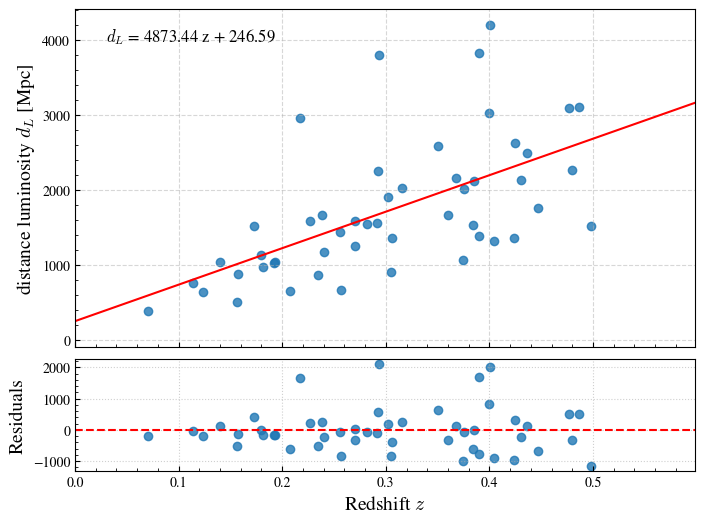

In [121]:
sign = '+' if theta[1] >= 0 else '-'
fig, ax = plt.subplots(nrows=2,figsize=(8, 6),sharex=True,gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
ax[0].scatter(z_sample, dL_sample, alpha=0.8)
ax[1].scatter(z_sample, dL_sample - dL_pred, alpha=0.8)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel('Redshift $z$', fontsize=14)
ax[1].set_ylabel('Residuals', fontsize=14)
ax[0].plot(z_fit, dL_fit, color='red', label='Linear Fit')
ax[0].set_ylabel(r'distance luminosity $d_L$ [Mpc]', fontsize=14)
ax[0].text(0.05, 0.95, fr'$d_L$ = {theta[1]:.2f} z {sign} {np.abs(theta[0]):.2f}', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].set_xlim(0.0, z_sample.max()+0.1)
ax[0].grid(True, linestyle='--', alpha=0.5)

#ax.legend()
plt.grid()
plt.show()

Libraries such as `scikit-learn` and `SciPy` already have these methods implemented. In this lecture, we will prioritize `scikit-learn` because it is the standard for Machine Learning and will be used frequently throughout the rest of this course. However, we also encourage you to explore the `SciPy` documentation.

In [122]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X, y)

intercept_sklearn = model.intercept_
slope_sklearn     = model.coef_[0]

print('Intercept (sklearn):', intercept_sklearn)
print('Slope (sklearn):', slope_sklearn)

dL_pred_sklearn = model.predict(X)
mse_sklearn     = mean_squared_error(y, dL_pred_sklearn)
print('MSE (sklearn):', mse_sklearn)

Intercept (sklearn): 246.59018149150643
Slope (sklearn): 4873.444262949442
MSE (sklearn): 502594.13818399893


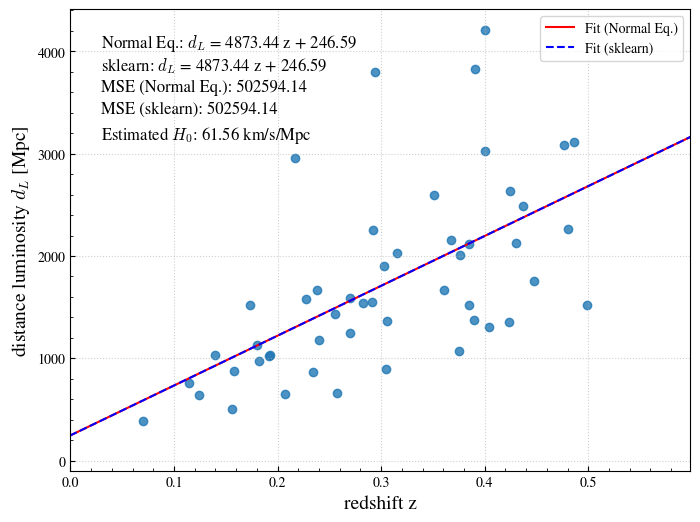

In [123]:
theta_sklearn  = np.array([intercept_sklearn, slope_sklearn])
dL_fit_sklearn = X_fit @ theta_sklearn 

sign = '+' if intercept_sklearn >= 0 else '-'
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(z_sample, dL_sample, alpha=0.8)
ax.plot(z_fit, dL_fit, color='red', label='Fit (Normal Eq.)')
ax.plot(z_fit, dL_fit_sklearn, color='blue', linestyle='--', label='Fit (sklearn)')
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance luminosity $d_L$ [Mpc]', fontsize=14)
ax.text(0.05, 0.95, fr'Normal Eq.: $d_L$ = {theta[1]:.2f} z {sign} {np.abs(theta[0]):.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.90, fr'sklearn: $d_L$ = {slope_sklearn:.2f} z {sign} {np.abs(intercept_sklearn):.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.85, f'MSE (Normal Eq.): {mse:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.80, f'MSE (sklearn): {mse_sklearn:.2f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.text(0.05, 0.75, fr'Estimated $H_0$: {CSPEED/slope_sklearn:.2f} km/s/Mpc', transform=ax.transAxes, fontsize=12, verticalalignment='top')
ax.set_xlim(0.0, z_sample.max()+0.1)
ax.legend()
plt.grid()
plt.show()

**General Case:** Standard OLS assumes that all errors are equal and independent. However, in real astronomical observations, this is rarely true. Each data point typically has a different uncertainty (instrumental noise), requiring us to work with the Error Covariance Matrix $\mathbf{C}$:

$$\mathbf{C} = \begin{bmatrix}\sigma_1^2 & \sigma_{12} & \dots & \sigma_{1n} \\
\sigma_{21} & \sigma_2^2 & \dots & \sigma_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
\sigma_{n1} & \sigma_{n2} & \dots & \sigma_n^2
\end{bmatrix}$$

Under the assumption of Gaussian noise, the Likelihood Function $L(\theta)$ for independent observations with different uncertainties $\sigma_i$ is:

$$L(\theta) \propto \exp \left(-\frac{1}{2} \sum_{i=1}^{n} \frac{(y_i - \mathbf{X}_i\theta)^2}{\sigma_i^2} \right)$$

In astronomy, we focus on the exponent of this distribution. This leads to the definition of $\chi^2$ (Chi-squared), which quantifies the goodness of fit:

$$\chi^2 = \sum_{i=1}^{n} \frac{(y_i - \hat{y}_i)^2}{\sigma_i^2}$$

When we consider the full covariance matrix (including potential correlations between observations), the cost function $J(\theta)$ is exactly the $\chi^2$ expressed in matrix form:

$$J(\theta) = \chi^2 = (\mathbf{y} - \mathbf{X}\theta)^T \mathbf{C}^{-1} (\mathbf{y} - \mathbf{X}\theta)$$

Maximizing the likelihood is equivalent to minimizing this cost function. The general analytical solution for the optimal parameters, known as Weighted Least Squares (WLS), is:

$$\hat{\theta} = \left(\mathbf{X}^T\mathbf{C}^{-1}\mathbf{X}\right)^{-1}\mathbf{X}^T \mathbf{C}^{-1} \mathbf{y}$$

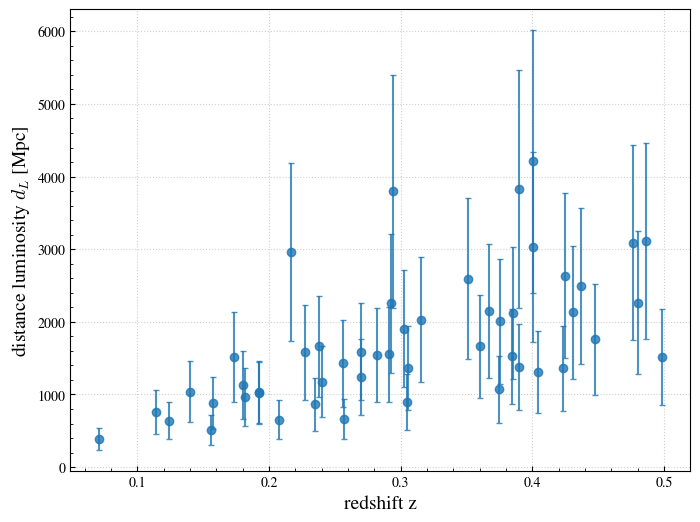

In [124]:
z_sample, mu_sample, dmu_sample  = astroML.datasets.generate_mu_z(100, random_state=42)
mask = z_sample < 0.5
z_sample, mu_sample, dmu_sample  = z_sample[mask], mu_sample[mask], dmu_sample[mask]

mu2dl      = lambda mu: 10**((mu - 25) / 5)
dL_sample  = mu2dl(mu_sample) #/ 1000 # Convert to Gpc
ddL_sample = dL_sample * (np.log(10) / 5) * dmu_sample

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(z_sample, dL_sample, yerr=ddL_sample, fmt='o', capsize=2, alpha=0.8)
ax.set_xlabel('redshift z', fontsize=14)
ax.set_ylabel(r'distance luminosity $d_L$ [Mpc]', fontsize=14)
plt.grid()
plt.show()

In [125]:
# Create the design matrix by adding a column of ones for the intercept term
X_mat = np.column_stack((np.ones(z_sample.shape), z_sample))

# We are assuming that the errors in dL sample are independent and normally distributed
# with variances given by ddL_sample**2.
# Inverse of the covariance matrix (weights)
Cinv = np.diag(1 / ddL_sample**2)

# Compute the weighted least squares solution
theta_weighted = np.linalg.inv(X_mat.T @ Cinv @ X_mat) @ X_mat.T @ Cinv @ dL_sample

print('Weighted Intercept:', theta_weighted[0])
print('Weighted Slope:', theta_weighted[1]) 

# Compute the chi-squared statistic
dL_pred = X_mat @ theta_weighted
chi_squared = np.sum(((dL_sample - dL_pred) / ddL_sample) ** 2)
print('Chi-squared:', chi_squared)

Weighted Intercept: 137.97900060621163
Weighted Slope: 3923.0124416732674
Chi-squared: 32.46006399192509


In [126]:
X_sklearn_weighted = z_sample.reshape(-1, 1)

# Weights (Inverse of Covariance Matrix)
weights = 1 / ddL_sample**2

model_weighted = LinearRegression()
model_weighted.fit(X_sklearn_weighted, dL_sample, sample_weight=weights)

print('Weighted Intercept:', model_weighted.intercept_)
print('Weighted Slope:', model_weighted.coef_[0])

dL_pred_weighted     = model_weighted.predict(X_sklearn_weighted)
chi_squared_weighted = np.sum(((dL_sample - dL_pred_weighted) / ddL_sample) ** 2)
print('Chi-squared (sklearn):', chi_squared_weighted)


Weighted Intercept: 137.97900060621112
Weighted Slope: 3923.0124416732697
Chi-squared (sklearn): 32.46006399192509


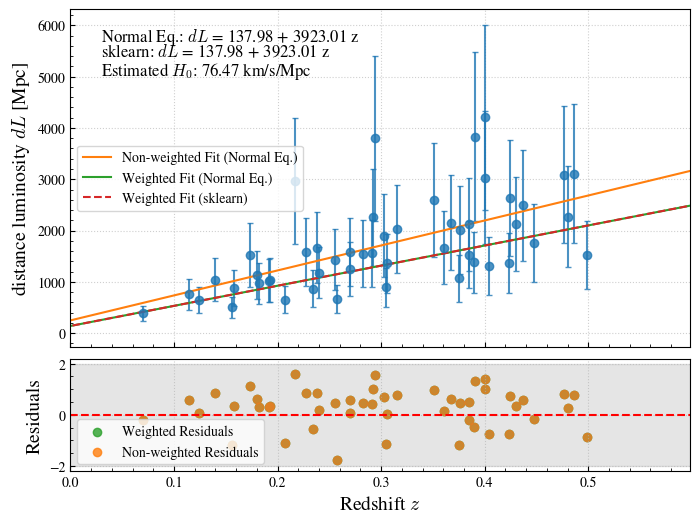

In [127]:
z_fit = np.linspace(z_sample.min()-0.1, z_sample.max()+0.1, 100).reshape(-1, 1)
X_fit_weighted = np.column_stack((np.ones(z_fit.shape[0]), z_fit))
dL_fit_weighted = X_fit_weighted @ theta_weighted
dL_fit_weighted_sklearn = model_weighted.predict(z_fit)

fig, ax = plt.subplots(nrows=2,figsize=(8, 6),sharex=True,gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
ax[0].errorbar(z_sample, dL_sample, yerr=ddL_sample, fmt='o', capsize=2, alpha=0.8)
ax[0].plot(z_fit, dL_fit, color='C1', label='Non-weighted Fit (Normal Eq.)')
ax[0].plot(z_fit, dL_fit_weighted, color='C2', label='Weighted Fit (Normal Eq.)')
ax[0].plot(z_fit, dL_fit_weighted_sklearn, color='C3', linestyle='--', label='Weighted Fit (sklearn)')
ax[0].set_ylabel(r'distance luminosity $dL$ [Mpc]', fontsize=14)
ax[0].text(0.05, 0.95, fr'Normal Eq.: $dL$ = {theta_weighted[0]:.2f} + {theta_weighted[1]:.2f} z', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].text(0.05, 0.90, fr'sklearn: $dL$ = {model_weighted.intercept_:.2f} + {model_weighted.coef_[0]:.2f} z', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].text(0.05, 0.85, fr'Estimated $H_0$: {CSPEED/model_weighted.coef_[0]:.2f} km/s/Mpc', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].set_xlim(0.0, z_sample.max()+0.1)
ax[0].legend()
ax[0].grid()

ax[1].scatter(z_sample, (dL_sample - dL_pred_weighted)/ddL_sample, alpha=0.8, color='C2', label='Weighted Residuals')
ax[1].scatter(z_sample, (dL_sample - dL_pred)/ddL_sample, alpha=0.8, color='C1', label='Non-weighted Residuals')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel('Redshift $z$', fontsize=14)
ax[1].set_ylabel('Residuals', fontsize=14)
ax[1].fill_between(z_fit.flatten(), -2, 2, color='gray', alpha=0.2)
ax[1].legend()

plt.grid()
plt.show()


Preguntas para ustedes,

¿Qué pasa si usamos todo el set de datos para entrenar y nada para testear?

¿Por qué OLS tiene problemas con datos complejos?

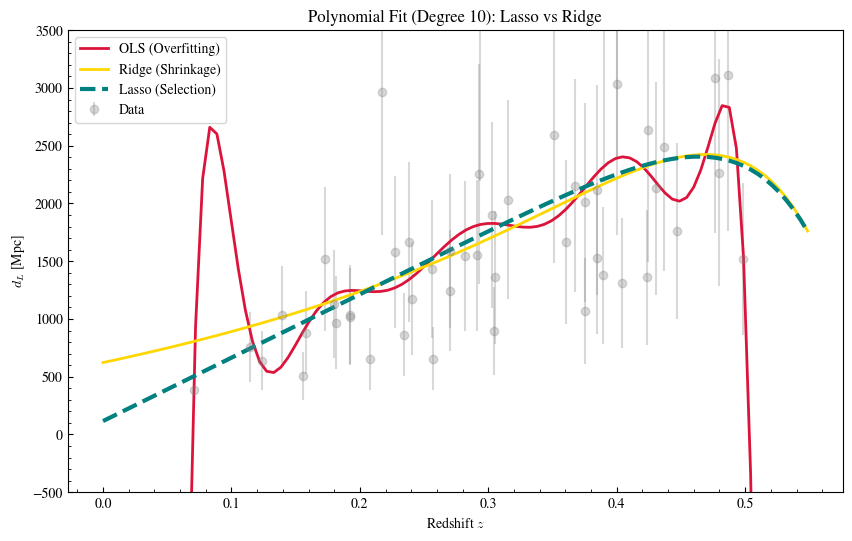

Lasso Coefficients (High-order terms):
z^0: 0.0000
z^1: 601.2537
z^2: 0.0000
z^3: 0.0000
z^4: -0.0000
z^5: -0.0000
z^6: -0.0000
z^7: -0.0000
z^8: -0.0000
z^9: -0.0000
z^10: -113.1418


In [129]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Increase complexity: 10th-degree polynomial
degree = 10
z_plot = np.linspace(0, z_sample.max() + 0.05, 100).reshape(-1, 1)

# 2. Define models
# We use a Pipeline because Scaling is MANDATORY for regularization
ols_poly = make_pipeline(PolynomialFeatures(degree), LinearRegression())
ridge_poly = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Ridge(alpha=10))
lasso_poly = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Lasso(alpha=10))

# 3. Fit
ols_poly.fit(X, y)
ridge_poly.fit(X, y)
lasso_poly.fit(X, y)

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, dL_sample, yerr=ddL_sample, fmt='o', alpha=0.3, label='Data', color='gray')

plt.plot(z_plot, ols_poly.predict(z_plot), label='OLS (Overfitting)', color='crimson', lw=2)
plt.plot(z_plot, ridge_poly.predict(z_plot), label='Ridge (Shrinkage)', color='gold', lw=2)
plt.plot(z_plot, lasso_poly.predict(z_plot), label='Lasso (Selection)', color='teal', lw=3, linestyle='--')

plt.ylim(-500, 3500)
plt.xlabel('Redshift $z$')
plt.ylabel('$d_L$ [Mpc]')
plt.title(f'Polynomial Fit (Degree {degree}): Lasso vs Ridge')
plt.legend()
plt.show()

# 5. PROOF: Print the coefficients
print("Lasso Coefficients (High-order terms):")
# The first coefficient is the intercept, the rest are z^1, z^2...
lasso_coefs = lasso_poly.named_steps['lasso'].coef_
for i, coef in enumerate(lasso_coefs):
    print(f"z^{i}: {coef:.4f}")

# Regularization: Ridge and Lasso

Ordinary Least Squares (OLS) can be prone to overfitting when there is a lot of noise in the data or when we have many correlated features. What can we do in that case? We introduce Regularization, which adds a penalty to the cost function to restrict the model's complexity.

There are two main approaches:

1. **Ridge Regression ($L_2$ Regularization):** Ridge penalizes high coefficients but keeps all features in the model. The cost function $J(\theta)$ adds an $L_2$ penalty term ($\alpha \theta^T \theta$) to the standard Residual Sum of Squares:

$$J(\theta) = (\mathbf{y} - \mathbf{X}\theta)^T \mathbf{C}^{-1} (\mathbf{y} - \mathbf{X}\theta) + \alpha\sum_{j=1}^p\theta_j^2 = (\mathbf{y} - \mathbf{X}\theta)^T \mathbf{C}^{-1} (\mathbf{y} - \mathbf{X}\theta) + \alpha\theta^T\theta$$

Following the same derivative steps derived previously, and knowing that the derivative of the penalty term is $\frac{\partial}{\partial \theta}(\alpha \theta^T \theta) = 2\alpha\theta$, we get:
$$\frac{\partial J(\theta)}{\partial \theta} = -2\mathbf{X}^T\mathbf{C}^{-1}\mathbf{y} + 2\mathbf{X}^T\mathbf{C}^{-1}\mathbf{X}\theta + 2\alpha\theta $$

Setting the gradient equal to $0$:
$$\mathbf{X}^T\mathbf{X}\hat{\theta} + \alpha\hat{\theta} = \mathbf{X}^T\mathbf{C}^{-1}\mathbf{y}$$

To factor out $\hat{\theta}$, we multiply the scalar $\alpha$ by the Identity Matrix $\mathbf{I}$ (since $\mathbf{I}\hat{\theta} = \hat{\theta}$):
$$
\begin{aligned}
\mathbf{X}^T\mathbf{X}\hat{\theta} + \alpha \mathbf{I} \hat{\theta} &= \mathbf{X}^T\mathbf{C}^{-1}\mathbf{y} \\
(\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I})\hat{\theta} &= \mathbf{X}^T\mathbf{C}^{-1}\mathbf{y}
\end{aligned}
$$
Finally, solving for $\hat{\theta}$, we find the analytical solution for Ridge:

$$\hat{\theta}_{ridge} = (\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I})^{-1}\mathbf{X}^T\mathbf{C}^{-1}\mathbf{y}$$

(Note: In practice, the intercept $\theta_0$ is not penalized, so the first element of the identity matrix $\mathbf{I}$ is set to $0$).


2. **Lasso Regression ($L_1$ Regularization):** Lasso applies an absolute value penalty. Its main advantage is that it can force some coefficients to become exactly zero, effectively performing automatic feature selection and simplifying the model.The cost function is:
$$J(\theta) = (\mathbf{y} - \mathbf{X}\theta)^T\mathbf{C}^{-1}(\mathbf{y} - \mathbf{X}\theta) + \alpha \sum_{j=1}^{p} |\theta_j|$$

Why is it not possible to obtain an analytical solution for $\hat{\theta}_{lasso}$?

How do we solve it? (Coordinate Descent)
Since we lack a simple formula, we must use numerical optimization algorithms like Coordinate Descent.

Regardless of the method chosen (Ridge or Lasso), $\alpha$ serves as a tuning hyperparameter. It controls the trade-off between fitting the training data perfectly and keeping the model weights small to prevent overfitting.

**The Role of $\alpha$ (The Penalty Term)**

- If $\alpha = 0$: The penalty disappears completely. The cost function becomes identical to the standard OLS (Ordinary Least Squares).
- If $\alpha \to \infty$: The penalty dominates the cost function. The model will force all coefficients ($\theta$) to approach zero, resulting in a flat horizontal line (a model that predicts the mean, suffering from underfitting).

How do we choose $\alpha$?

Since $\alpha$ is a hyperparameter, it is not learned by the Normal Equation or Coordinate Descent. We, as astronomers/data scientists, must find the optimal value through Cross-Validation, testing different values of $\alpha$ to see which one yields the lowest error on unseen data.

Lasso Chi-squared: 32.46006600742351
Ridge Chi-squared: 74.73680177652705


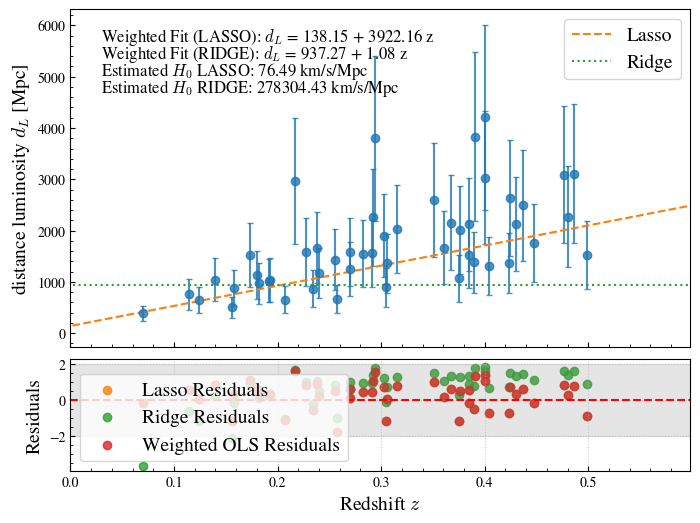

In [128]:
from sklearn.linear_model import Ridge, Lasso

# Fit Lasso and Ridge
alpha = 0.01
#alpha = 1e-9
weights = 1 / ddL_sample**2
#weights = weights / np.mean(weights)

lasso = Lasso(alpha=alpha)
ridge = Ridge(alpha=alpha)
lasso.fit(X_sklearn_weighted, dL_sample, sample_weight=weights)
ridge.fit(X_sklearn_weighted, dL_sample, sample_weight=weights)

z_fit = np.linspace(z_sample.min()-0.1, z_sample.max()+0.1, 100).reshape(-1, 1)
X_fit_weighted = np.column_stack((np.ones(z_fit.shape[0]), z_fit))
dL_fit_weighted_lasso = lasso.predict(z_fit)
dL_fit_weighted_ridge = ridge.predict(z_fit)

# Predecimos
y_pred_lasso = lasso.predict(X_sklearn_weighted)
y_pred_ridge = ridge.predict(X_sklearn_weighted)

print('Lasso Chi-squared:', np.sum(((dL_sample - y_pred_lasso) / ddL_sample) ** 2))
print('Ridge Chi-squared:', np.sum(((dL_sample - y_pred_ridge) / ddL_sample) ** 2))

# Comparamos modelos
fig, ax = plt.subplots(nrows=2, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
ax[0].errorbar(z_sample, dL_sample, yerr=ddL_sample, fmt='o', capsize=2, alpha=0.8)
#ax.plot(X, y_pred, color="red", label="OLS")
ax[0].plot(z_fit, dL_fit_weighted_lasso,color='C1',linestyle="dashed", label="Lasso")
ax[0].plot(z_fit, dL_fit_weighted_ridge,color='C2',linestyle="dotted", label="Ridge")
ax[0].text(0.05, 0.95, fr'Weighted Fit (LASSO): $d_L$ = {lasso.intercept_:.2f} + {lasso.coef_[0]:.2f} z', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].text(0.05, 0.90, fr'Weighted Fit (RIDGE): $d_L$ = {ridge.intercept_:.2f} + {ridge.coef_[0]:.2f} z', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].text(0.05, 0.85, fr'Estimated $H_0$ LASSO: {CSPEED/lasso.coef_[0]:.2f} km/s/Mpc', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[0].text(0.05, 0.80, fr'Estimated $H_0$ RIDGE: {CSPEED/ridge.coef_[0]:.2f} km/s/Mpc', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')

ax[0].set_ylabel(r'distance luminosity $d_L$ [Mpc]', fontsize=14)
ax[0].legend(fontsize=14)
ax[0].set_xlim(0.0, z_sample.max()+0.1)

ax[1].scatter(z_sample, (dL_sample - y_pred_lasso)/ddL_sample, alpha=0.8, color='C1', label='Lasso Residuals')
ax[1].scatter(z_sample, (dL_sample - y_pred_ridge)/ddL_sample, alpha=0.8, color='C2', label='Ridge Residuals')
ax[1].scatter(z_sample, (dL_sample - dL_pred_weighted)/ddL_sample, alpha=0.8, color='C3', label='Weighted OLS Residuals')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel('Redshift $z$', fontsize=14)
ax[1].set_ylabel('Residuals', fontsize=14)
ax[1].fill_between(z_fit.flatten(), -2, 2, color='gray', alpha=0.2)
ax[1].legend(fontsize=14)
ax[1].set_xlim(0.0, z_sample.max()+0.1)

plt.grid()
plt.show()

# Huber Regression

In many astronomical datasets, we encounter outliers—data points that deviate significantly from the rest of the sample due to instrumental glitches, cosmic rays, or misclassifications. When outliers are present, Ordinary Least Squares (OLS) fails to provide a reliable fit because the squared nature of its cost function ($L_2$ loss) disproportionately penalizes large residuals. This "pulls" the regression line toward the outliers, compromising the model's accuracy for the majority of the data.

To address this, we use Huber Regression, a robust estimation technique that combines the best properties of OLS and Mean Absolute Error ($L_1$ loss). The Huber loss function $L_\delta(r)$ is defined piecewise:

$$L_\delta(r) = 
\begin{cases} 
\frac{1}{2}r^2 & \text{for } |r| \leq \delta \\
\delta(|r| - \frac{1}{2}\delta) & \text{for } |r| > \delta 
\end{cases}$$

Where $r = y - \mathbf{X}\theta$ is the residual and $\delta$ (delta) is a threshold parameter.
Why is it more robust?
- For small residuals ($|r| \leq \delta$): It behaves like OLS, being quadratic and differentiable at the origin, which ensures stable convergence and high efficiency for normally distributed noise.
- For large residuals ($|r| > \delta$): It behaves like Lasso/MAE ($L_1$), increasing linearly rather than quadratically. This limits the influence of outliers on the final fit, preventing them from dominating the optimization process.

By adjusting the threshold $\delta$, we can control the model's sensitivity to outliers, making Huber Regression an essential tool for creating stable cosmological models from noisy observational data.

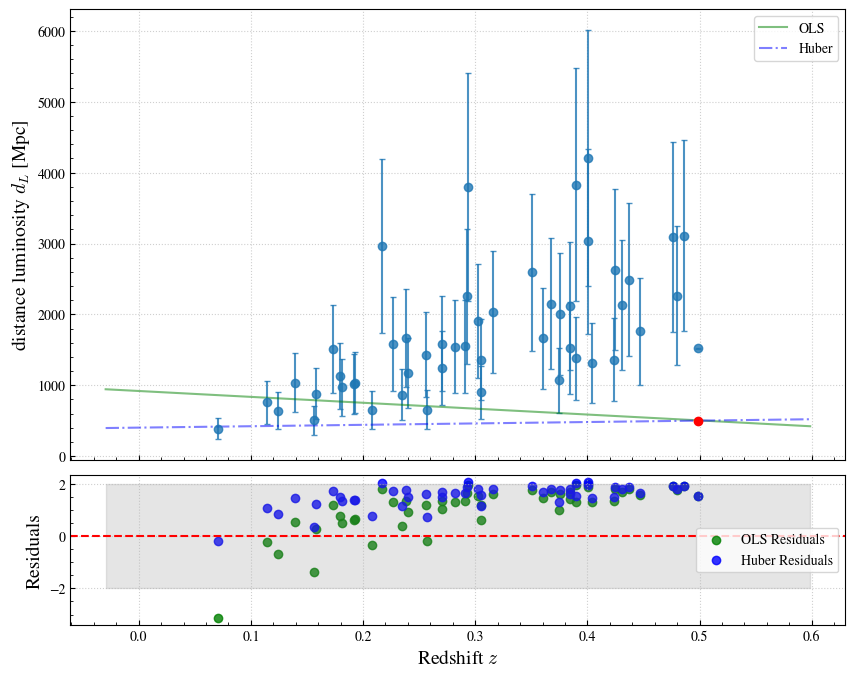

In [114]:
from sklearn.linear_model import HuberRegressor

z_sample, mu_sample, dmu_sample  = astroML.datasets.generate_mu_z(100, random_state=42)
mask = z_sample < 0.5
z_sample, mu_sample, dmu_sample  = z_sample[mask], mu_sample[mask], dmu_sample[mask]
idx_z_sorted = np.argsort(z_sample) # Sort by redshift for better visualization
z_sample, mu_sample, dmu_sample = z_sample[idx_z_sorted], mu_sample[idx_z_sorted], dmu_sample[idx_z_sorted]

mu2dl      = lambda mu: 10**((mu - 25) / 5)
dL_sample  = mu2dl(mu_sample) #/ 1000 # Convert to Gpc
ddL_sample = dL_sample * (np.log(10) / 5) * dmu_sample

X = z_sample.reshape(-1, 1)
y = dL_sample
weights = 1 / (ddL_sample)**2  # Pesos inversamente proporcionales a la varianza

y_outliers = y.copy()
#y_outliers[0]  += 2500  # Agregamos errores grandes
#y_outliers[10] -= 1500  # Agregamos errores grandes
y_outliers[-1] = 500
weights[-1]    = 1/(10**2)

# Fit OLS Regression
ols = LinearRegression().fit(X, y_outliers, sample_weight=weights)

# Fit Huber Regression
# epsilon=1.35 es el estándar; determina qué tan "lejos" debe estar un punto para ser ignorado
huber = HuberRegressor(epsilon=1.0, alpha=0).fit(X, y_outliers, sample_weight=weights)

# Predecimos
z_fit = np.linspace(z_sample.min()-0.1, z_sample.max()+0.1, 100).reshape(-1, 1)
y_fit_ols = ols.predict(z_fit)
y_fit_huber = huber.predict(z_fit)

# Comparamos modelos
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10,8), sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
ax[0].errorbar(X, y, yerr=1/np.sqrt(weights), fmt='o', capsize=2, alpha=0.8)
#ax[0].errorbar(X[0], y_outliers[0], yerr=1/np.sqrt(weights[0]), color='red', fmt='o', capsize=2)
#ax[0].errorbar(X[10], y_outliers[10], yerr=1/np.sqrt(weights[10]), color='red', fmt='o', capsize=2)
ax[0].errorbar(X[-1], y_outliers[-1], yerr=1/np.sqrt(weights[-1]), color='red', fmt='o', capsize=2)
ax[0].plot(z_fit, y_fit_ols, color="green", linestyle="solid", label="OLS",alpha=0.5)
ax[0].plot(z_fit, y_fit_huber, color="blue", linestyle="dashdot", label="Huber",alpha=0.5)
ax[0].set_ylabel(r'distance luminosity $d_L$ [Mpc]', fontsize=14)
ax[0].legend()
ax[0].grid()

ax[1].scatter(X, (y - ols.predict(X))/ddL_sample, alpha=0.8, color='green', label='OLS Residuals')
ax[1].scatter(X, (y - huber.predict(X))/ddL_sample, alpha=0.8, color='blue', label='Huber Residuals')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_xlabel('Redshift $z$', fontsize=14)
ax[1].set_ylabel('Residuals', fontsize=14)
ax[1].fill_between(z_fit.flatten(), -2, 2, color='gray', alpha=0.2)
ax[1].legend()

plt.grid()
plt.show()

| Methodology | Mathematical Core | Key Hyperparameter | Best Astro Use-Case |
| :--- | :--- | :--- | :--- |
| **OLS / WLS** | $\sum w_i (y_i - \hat{y}_i)^2$ | None (Analytical) | **The Standard:** High-quality datasets with well-estimated Gaussian errors (e.g., Hubble Diagram with low-z SNe). |
| **Ridge ($L_2$)** | $\text{WLS} + \alpha \sum \theta^2$ | `alpha` ($\alpha$) | **Stability:** When features are redundant or highly correlated (e.g., predicting mass using multiple photometric bands). |
| **Lasso ($L_1$)** | $\text{WLS} + \alpha \sum \theta$ | `alpha` ($\alpha$) | **Parsimony:** Automatic feature selection (e.g., identifying the most relevant spectral lines out of hundreds). |
| **Huber** | Piecewise ($L_2$ to $L_1$) | `epsilon` ($\delta$) | **Robustness:** Cleaning data contaminated by cosmic rays, satellite trails, or "liar" outliers with fake high precision. |   |

# 3D Case

The structural properties of elliptical galaxies are not independent; they follow a tight correlation known as the Fundamental Plane. We can estimate the effective radius ($R_e$), which represents the size of the galaxy, using the following empirical relation:

$$\log R_e = \theta_0 + \theta_1 \log \sigma + \theta_2 \mu_e$$

Where $\sigma$ is the central velocity dispersion (kinematics) and $\mu_e$ is the mean surface brightness (photometry). In a 3D parameter space, elliptical galaxies do not scatter randomly but rather cluster on a thin, two-dimensional sheet

Coefficients: [-0.24854183 -0.15035158]
Intercept: -3.313695
Mean Squared Error: 0.04567750543355942


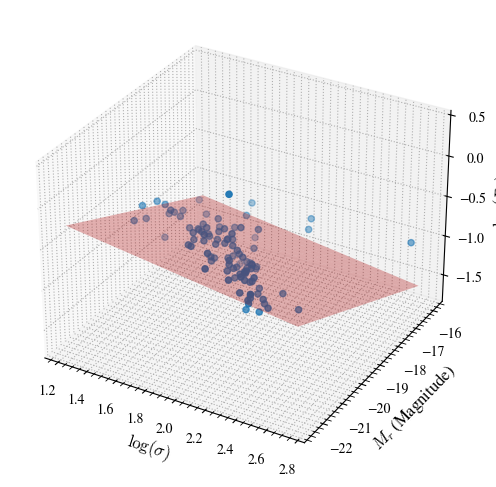

In [84]:
# Fetching real galaxy data
data_raw = astroML.datasets.fetch_nasa_atlas()

mask = (data_raw['VDISP'] > 0) & (data_raw['Z'] > 0) & (data_raw['PETROTH50'] > 0)
data = data_raw[mask]
data = pd.DataFrame({
    # Convertimos el radio angular a radio físico aproximado usando el redshift (Z)
    'log_Re': np.log10(data['PETROTH50'] * data['Z']),
    # Logaritmo de la dispersión de velocidades
    'log_sigma': np.log10(data['VDISP']),
    # Magnitud absoluta en banda r (índice 4 del vector ABSMAG)
    'Mr': data['ABSMAG'][:,4]
})
data = data.replace([np.inf, -np.inf], np.nan).dropna()
data.reset_index(drop=True, inplace=True)
data = data.iloc[::len(data)//100]  # Limitamos a 100 galaxias para acelerar el proceso


# Defined the features (X) and target variable (y)
X = data[['log_sigma','Mr']]
y = data['log_Re']

model = LinearRegression()
model.fit(X.values, y.values)

y_pred = model.predict(X.values)
mse    = mean_squared_error(y.values, y_pred)

print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean Squared Error:', mse)

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': '3d'})

ax.scatter(data['log_sigma'], data['Mr'], data['log_Re'], label='Galaxies')

# 2. Creamos la malla para representar el plano de ajuste
x_range = np.linspace(data['log_sigma'].min(), data['log_sigma'].max(), 20)
y_range = np.linspace(data['Mr'].min(), data['Mr'].max(), 20)
x_mesh, y_mesh = np.meshgrid(x_range, y_range)

# Predicción sobre la malla (necesitamos aplanarla para el modelo)
mesh_points = np.c_[x_mesh.ravel(), y_mesh.ravel()]
z_mesh = model.predict(mesh_points).reshape(x_mesh.shape)

# 3. Graficamos el plano (superficie)
ax.plot_surface(x_mesh, y_mesh, z_mesh, color='red', alpha=0.3)

# Etiquetas y Estilo
ax.set_xlabel(r'$\log(\sigma)$', fontsize=12)
ax.set_ylabel(r'$M_r$ (Magnitude)', fontsize=12)
ax.set_zlabel(r'$\log(R_e)$', fontsize=12)

plt.show()

1. Crítica Técnica: El "Pecado" de la RegularizaciónEl notebook introduce Ridge y Lasso, pero omite un paso que es mandatorio en Machine Learning: Feature Scaling (Estandarización).El Problema: La regularización penaliza el tamaño de los coeficientes $\theta$. En tu caso, $z$ varía de $0$ a $0.5$, mientras que $d_L$ llega a $2000$. La pendiente resultante es enorme ($\sim 4000$).La Consecuencia: Si un estudiante usa un $\alpha=1$, el modelo colapsará inmediatamente porque el castigo al coeficiente $4000$ es astronómico comparado con el error de los datos.Sugerencia: Agrega una nota o una celda usando StandardScaler. Explica que para que $\alpha$ tenga sentido, las características deben estar en la misma escala.2. El Dilema del Intercepto ($\theta_0$)Desde el punto de vista físico, la Ley de Hubble dicta que si $z=0$, entonces $d_L=0$.Crítica: En tus modelos estás dejando que el intercepto sea libre. Esto es estadísticamente correcto para un ejercicio de ajuste, pero físicamente cuestionable.Sugerencia: ¿Por qué no proponerles un reto? "¿Qué pasa con el MSE si forzamos al modelo a pasar por el origen?" (usar fit_intercept=False en sklearn). Esto les enseña la diferencia entre un modelo puramente estadístico y un modelo motivado por la física.3. Falta el Corazón del Machine Learning: ValidaciónEl notebook trata la regresión más como un "ajuste de curvas" (Curve Fitting) que como "aprendizaje automático" (Machine Learning).Crítica: No hay una división de datos en Train y Test.Sugerencia: Aunque sean solo 100 puntos, diles que entrenen con 80 y evalúen con 20. Es la única forma real de demostrar que Lasso/Ridge previenen el sobreajuste (overfitting). Sin un Test Set, el concepto de "generalización" se queda en la teoría.4. Análisis de ResiduosCalculas el MSE y el $\chi^2$, lo cual está muy bien, pero falta la inspección visual del error.Sugerencia: Agrega un Residual Plot ($z$ vs. $y - \hat{y}$).Por qué: Al graficar los residuos, los alumnos verán inmediatamente una "curva" en los errores a altos redshifts. Esto es una evidencia visual de que el modelo lineal es insuficiente para la cosmología real y justifica por qué necesitamos modelos más complejos (como $\Lambda$CDM).¿Qué le agregaría para que sea "Pro"?Cross-Validation (RidgeCV / LassoCV): En lugar de elegir $\alpha=0.1$ al azar, enséñales que el modelo puede "aprender" el mejor $\alpha$ por sí mismo. Es una celda de código adicional que les vuela la cabeza.Unidades y Constantes: Definir una celda de "Constantes Físicas" al principio (usando astropy.constants o units) le daría un toque mucho más profesional y evitaría errores de "dedo" con la velocidad de la luz.Comparación de Métricas: Una pequeña tabla al final (usando pandas) que compare:OLS: MSE, $\chi^2$, $H_0$ estimado.Ridge: MSE, $\chi^2$, $H_0$ estimado.Huber: MSE, $\chi^2$, $H_0$ estimado.